In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.model_selection import ParameterGrid
from sklearn.decomposition import PCA

Step 2.
- делим title на brand и model
- делаем нормальный color(там тоже приколы а-ля  Комплектация Action • Серый вот такое чиним)
- С помощью remove_outliers_iqr удаляем выбросы хз мб была какая-то чту из либы для этого но ладно

In [2]:
def remove_outliers_iqr(data, column, threshold=1.2):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

In [3]:
df = pd.read_csv('./data/cars_data.csv')
df = df.drop_duplicates()
df['mileage'] = df['mileage'].fillna(0)
df['brand'] = df['title'].str.split(',').str[0].str.split().str[0]
df['model'] = df['title'].str.split(',').str[0].str.split().str[1]
df['color_clean'] = df['color'].str.split('•').str[-1]

In [4]:
df_clean = remove_outliers_iqr(df, 'price', threshold=2.0)
df_clean = remove_outliers_iqr(df_clean, 'engine_power_hp', threshold=2.0)
df = df_clean.copy()
df = df.drop(['title', 'color'], axis=1)
categorical_cols = ['brand', 'color_clean', 'body', 'wd', 'transmission', 'model']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [5]:
price_original = df_encoded['price'].copy()
X_clustering = df_encoded.drop('price', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

numeric_features = ['year', 'mileage', 'price', 'engine_volume_l', 'engine_power_hp']
X_numeric = df[numeric_features].copy()

графики
- Можно сделать прикольные выводы

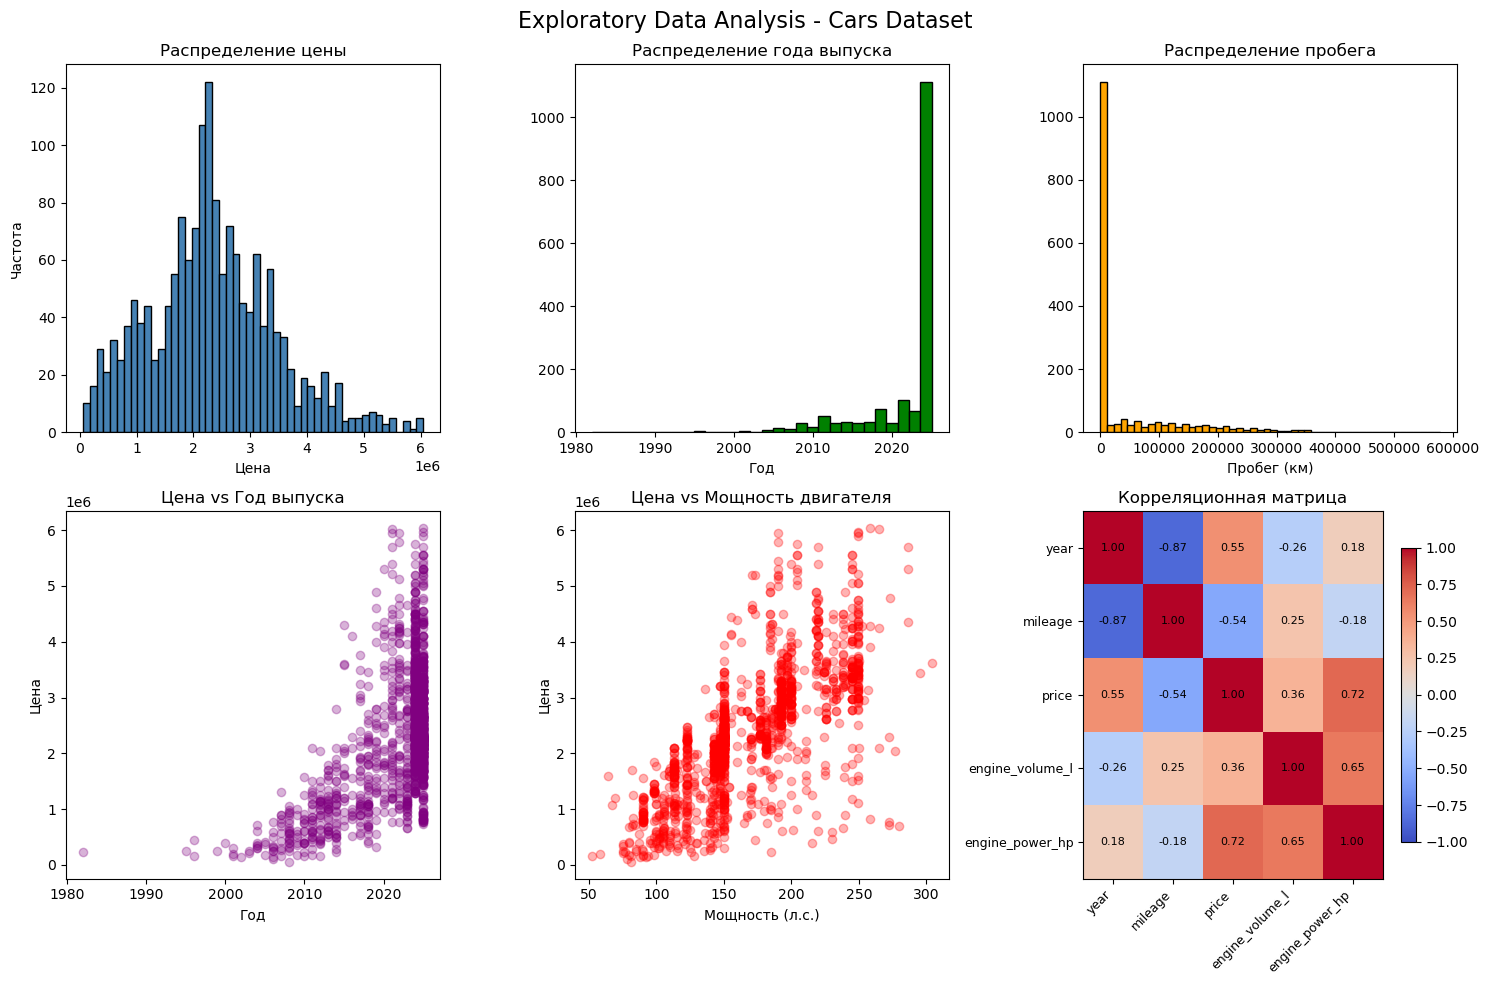

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Exploratory Data Analysis - Cars Dataset', fontsize=16)

axes[0, 0].hist(X_numeric['price'].dropna(), bins=50, edgecolor='black', color='steelblue')
axes[0, 0].set_title('Распределение цены')
axes[0, 0].set_xlabel('Цена')
axes[0, 0].set_ylabel('Частота')

axes[0, 1].hist(X_numeric['year'], bins=30, edgecolor='black', color='green')
axes[0, 1].set_title('Распределение года выпуска')
axes[0, 1].set_xlabel('Год')

axes[0, 2].hist(X_numeric['mileage'].dropna(), bins=50, edgecolor='black', color='orange')
axes[0, 2].set_title('Распределение пробега')
axes[0, 2].set_xlabel('Пробег (км)')

axes[1, 0].scatter(X_numeric['year'], X_numeric['price'], alpha=0.3, color='purple')
axes[1, 0].set_title('Цена vs Год выпуска')
axes[1, 0].set_xlabel('Год')
axes[1, 0].set_ylabel('Цена')

axes[1, 1].scatter(X_numeric['engine_power_hp'], X_numeric['price'], alpha=0.3, color='red')
axes[1, 1].set_title('Цена vs Мощность двигателя')
axes[1, 1].set_xlabel('Мощность (л.с.)')
axes[1, 1].set_ylabel('Цена')

corr_matrix = X_numeric.corr()
im = axes[1, 2].imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[1, 2].set_xticks(range(len(corr_matrix.columns)))
axes[1, 2].set_yticks(range(len(corr_matrix.columns)))
axes[1, 2].set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9)
axes[1, 2].set_yticklabels(corr_matrix.columns, fontsize=9)
axes[1, 2].set_title('Корреляционная матрица')

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = axes[1, 2].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                              ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, ax=axes[1, 2], shrink=0.8)

plt.tight_layout()
plt.show()


Step 3 Baseline решение с наивной реализацией кластеризации на основе цены

In [7]:
class BaselineClustering:
    def __init__(self, n_clusters=5):
        self.n_clusters = n_clusters
        self.cluster_names = {}
    
    def fit_predict(self, prices):
        quantiles = np.percentile(prices, np.linspace(0, 100, self.n_clusters + 1))
        labels = np.digitize(prices, quantiles[1:-1])
        
        for i in range(self.n_clusters):
            self.cluster_names[i] = f'Price range {i+1}: {quantiles[i]:.0f}-{quantiles[i+1]:.0f}'
        
        return labels

baseline = BaselineClustering(n_clusters=5)
baseline_labels = baseline.fit_predict(price_original)

baseline_silhouette = silhouette_score(X_scaled, baseline_labels)
baseline_calinski = calinski_harabasz_score(X_scaled, baseline_labels)
baseline_davies = davies_bouldin_score(X_scaled, baseline_labels)
baseline_inertia = sum([np.sum((X_scaled[baseline_labels == i] - 
                                X_scaled[baseline_labels == i].mean(axis=0))**2) 
                        for i in range(baseline.n_clusters)])

print("Baseline кластеры на основе цены:")
for i, name in baseline.cluster_names.items():
    count = np.sum(baseline_labels == i)
    print(f"  Кластер {i}: {name} - {count} автомобилей")

print(f"\nБазовые метрики:")
print(f"  Silhouette Score: {baseline_silhouette:.4f}")
print(f"  Calinski-Harabasz Index: {baseline_calinski:.2f}")
print(f"  Davies-Bouldin Index: {baseline_davies:.4f}")


Baseline кластеры на основе цены:
  Кластер 0: Price range 1: 55000-1399000 - 327 автомобилей
  Кластер 1: Price range 2: 1399000-2096400 - 330 автомобилей
  Кластер 2: Price range 3: 2096400-2499200 - 329 автомобилей
  Кластер 3: Price range 4: 2499200-3198600 - 328 автомобилей
  Кластер 4: Price range 5: 3198600-6045000 - 329 автомобилей

Базовые метрики:
  Silhouette Score: -0.0944
  Calinski-Harabasz Index: 7.61
  Davies-Bouldin Index: 10.4380


Step 4 выбор модели
- Думаю стоить взять K-means 

Step 5 Sklearn 

/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


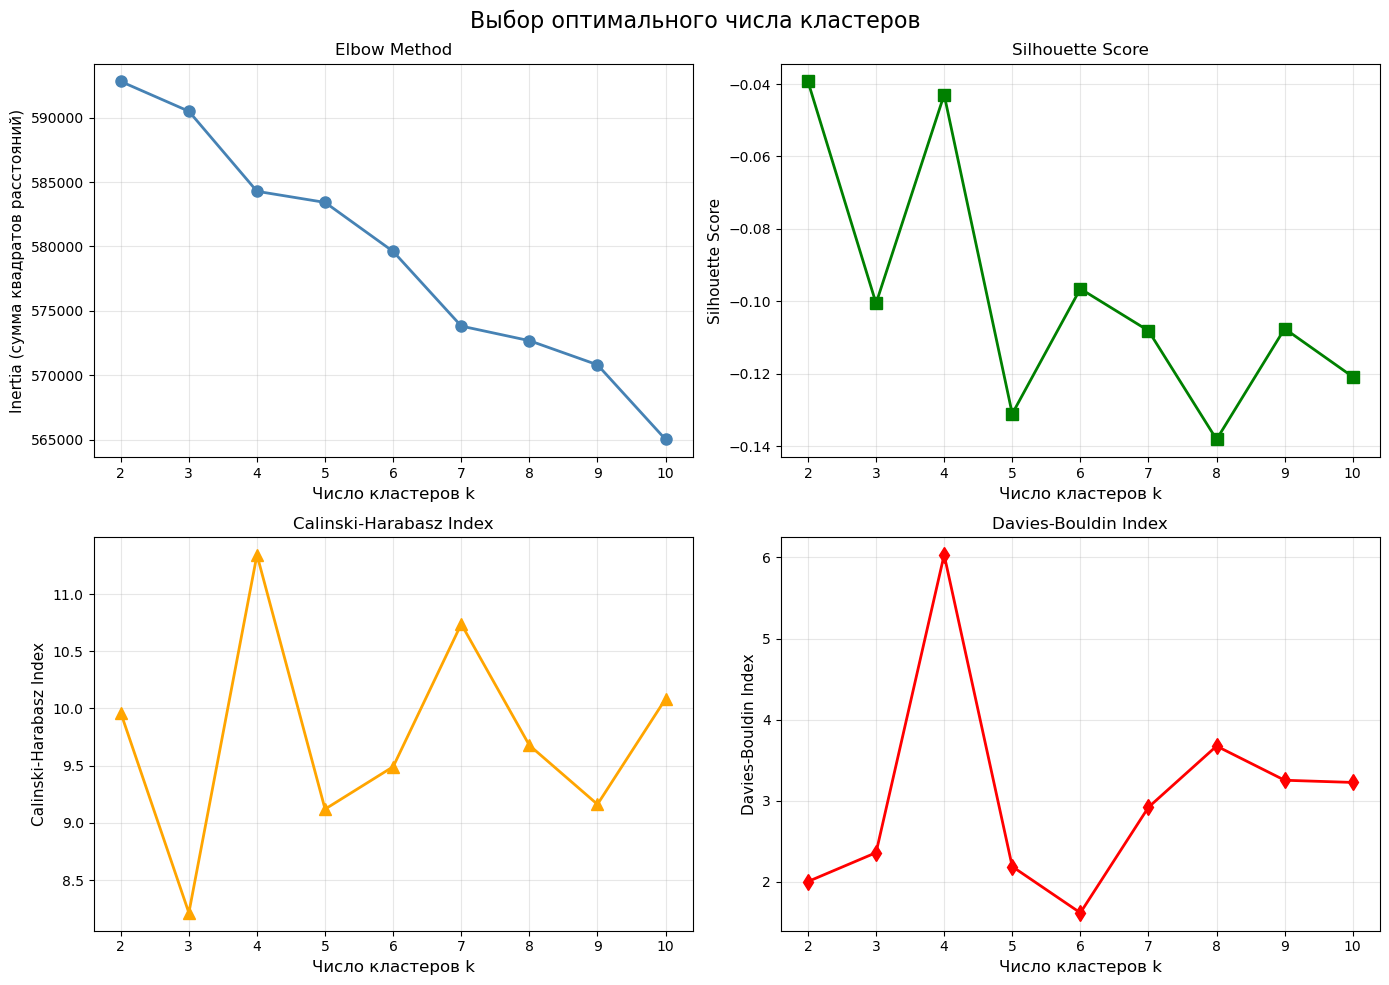


Оптимальное k по Silhouette Score: 2
Максимальный Silhouette Score: -0.0393


In [8]:
k_range = range(2, 11)
inertias = []
silhouettes = []
calinski_scores = []
davies_bouldin_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Выбор оптимального числа кластеров', fontsize=16)

axes[0, 0].plot(k_range, inertias, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0, 0].set_xlabel('Число кластеров k', fontsize=12)
axes[0, 0].set_ylabel('Inertia (сумма квадратов расстояний)', fontsize=11)
axes[0, 0].set_title('Elbow Method')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(k_range, silhouettes, marker='s', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('Число кластеров k', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 1].set_title('Silhouette Score')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(k_range, calinski_scores, marker='^', linewidth=2, markersize=8, color='orange')
axes[1, 0].set_xlabel('Число кластеров k', fontsize=12)
axes[1, 0].set_ylabel('Calinski-Harabasz Index', fontsize=11)
axes[1, 0].set_title('Calinski-Harabasz Index')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(k_range, davies_bouldin_scores, marker='d', linewidth=2, markersize=8, color='red')
axes[1, 1].set_xlabel('Число кластеров k', fontsize=12)
axes[1, 1].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[1, 1].set_title('Davies-Bouldin Index')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k_silhouette = k_range[np.argmax(silhouettes)]
print(f"\nОптимальное k по Silhouette Score: {optimal_k_silhouette}")
print(f"Максимальный Silhouette Score: {max(silhouettes):.4f}")


Step 6

In [9]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    'n_clusters': [2, 3, 4, 6, 7, 9],
    'init': ['k-means++', 'random'],
    'max_iter': [100, 200, 300],
    'n_init': [10, 20, 30],
    'tol': [1e-5, 1e-4, 1e-3, 1e-2]
}

best_score = -1
best_params = None
best_model = None
results = []

for params in ParameterGrid(param_grid):
    kmeans = KMeans(**params, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    
    results.append({
        'params': params,
        'silhouette': score,
        'inertia': kmeans.inertia_
    })
    
    if score > best_score:
        best_score = score
        best_params = params
        best_model = kmeans

print("Лучшие гиперпараметры:")
for key, value in best_params.items():
    print(f"  {key}: {value}")
print(f"\nЛучший Silhouette Score: {best_score:}")

Лучшие гиперпараметры:
  init: k-means++
  max_iter: 100
  n_clusters: 6
  n_init: 20
  tol: 1e-05

Лучший Silhouette Score: 0.1800345288843049


Step 7

In [10]:
final_kmeans = KMeans(**best_params, random_state=42)
final_labels = final_kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, final_labels)
final_calinski = calinski_harabasz_score(X_scaled, final_labels)
final_davies = davies_bouldin_score(X_scaled, final_labels)

print("Финальные метрики sklearn k-means")
print(f"Silhouette Score: {final_silhouette:.4f}")
print(f"Calinski-Harabasz Index: {final_calinski:.2f}")
print(f"Davies-Bouldin Index: {final_davies:.4f}")
print(f"Inertia: {final_kmeans.inertia_:.2f}")

df_analysis = pd.DataFrame(X_clustering)
df_analysis['cluster'] = final_labels
df_analysis['price'] = price_original

print("Характеристики кластеров")

for cluster_id in range(best_params['n_clusters']):
    cluster_data = df_analysis[df_analysis['cluster'] == cluster_id]
    cluster_prices = cluster_data['price']
    
    print(f"\nКластер {cluster_id}:")
    print(f"  Размер: {len(cluster_data)} автомобилей ({len(cluster_data)/len(df_analysis)*100:.1f}%)")
    print(f"  Средняя цена: {cluster_prices.mean():.0f} руб.")
    print(f"  Медианная цена: {cluster_prices.median():.0f} руб.")
    print(f"  Min-Max цена: {cluster_prices.min():.0f} - {cluster_prices.max():.0f} руб.")


Финальные метрики sklearn k-means
Silhouette Score: 0.1800
Calinski-Harabasz Index: 9.81
Davies-Bouldin Index: 3.8065
Inertia: 579056.11
Характеристики кластеров

Кластер 0:
  Размер: 2 автомобилей (0.1%)
  Средняя цена: 417500 руб.
  Медианная цена: 417500 руб.
  Min-Max цена: 370000 - 465000 руб.

Кластер 1:
  Размер: 285 автомобилей (17.3%)
  Средняя цена: 1213930 руб.
  Медианная цена: 950000 руб.
  Min-Max цена: 55000 - 5395000 руб.

Кластер 2:
  Размер: 1305 автомобилей (79.4%)
  Средняя цена: 2610807 руб.
  Медианная цена: 2449000 руб.
  Min-Max цена: 249900 - 6045000 руб.

Кластер 3:
  Размер: 24 автомобилей (1.5%)
  Средняя цена: 2309858 руб.
  Медианная цена: 1750000 руб.
  Min-Max цена: 299000 - 5450000 руб.

Кластер 4:
  Размер: 25 автомобилей (1.5%)
  Средняя цена: 951840 руб.
  Медианная цена: 915000 руб.
  Min-Max цена: 250000 - 2100000 руб.

Кластер 5:
  Размер: 2 автомобилей (0.1%)
  Средняя цена: 3085500 руб.
  Медианная цена: 3085500 руб.
  Min-Max цена: 2957000 - 32

Step 8

In [11]:
class CustomKMeans: 
    def __init__(self, n_clusters=5, max_iter=300, tol=1e-4, init_method='kmeans++', n_init=10, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.init_method = init_method
        self.n_init = n_init
        self.random_state = random_state
        
        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0
        self.history_ = []
        
    def _initialize_centers(self, X, random_seed):
        np.random.seed(random_seed)
        n_samples = X.shape[0]
        
        init = self.init_method.replace('-', '')
        
        if init == 'random':
            indices = np.random.choice(n_samples, self.n_clusters, replace=False)
            centers = X[indices].copy()
            
        elif init == 'kmeans++':
            centers = np.zeros((self.n_clusters, X.shape[1]))
            centers[0] = X[np.random.randint(n_samples)]
            
            for i in range(1, self.n_clusters):
                distances = np.min([np.linalg.norm(X - c, axis=1)**2 for c in centers[:i]], axis=0)
                probabilities = distances / distances.sum()
                cumulative_probs = probabilities.cumsum()
                r = np.random.rand()
                
                for j, p in enumerate(cumulative_probs):
                    if r < p:
                        centers[i] = X[j]
                        break
        else:
            raise ValueError(f"Unknown init_method: {self.init_method}")
            
        return centers
    
    def _assign_clusters(self, X, centers):
        distances = np.zeros((X.shape[0], self.n_clusters))
        
        for i, center in enumerate(centers):
            distances[:, i] = np.linalg.norm(X - center, axis=1)
        
        return np.argmin(distances, axis=1)
    
    def _update_centers(self, X, labels):
        new_centers = np.zeros((self.n_clusters, X.shape[1]))
        
        for i in range(self.n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                new_centers[i] = cluster_points.mean(axis=0)
            else:
                new_centers[i] = X[np.random.randint(X.shape[0])]
        
        return new_centers
    
    def _calculate_inertia(self, X, labels, centers):
        inertia = 0.0
        for i in range(self.n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                inertia += np.sum((cluster_points - centers[i])**2)
        return inertia
    
    def _fit_single(self, X, random_seed):
        centers = self._initialize_centers(X, random_seed)
        history = []

        for iteration in range(self.max_iter):
            labels = self._assign_clusters(X, centers)
            inertia = self._calculate_inertia(X, labels, centers)
            history.append(inertia)
            
            new_centers = self._update_centers(X, labels)
            center_shift = np.linalg.norm(new_centers - centers)
            
            centers = new_centers
            n_iter = iteration + 1
            
            if center_shift < self.tol:
                break
        
        labels = self._assign_clusters(X, centers)
        inertia = self._calculate_inertia(X, labels, centers)
        
        return centers, labels, inertia, n_iter, history
    
    def fit(self, X):
        best_inertia = np.inf
        best_centers = None
        best_labels = None
        best_n_iter = 0
        best_history = []
        
        for i in range(self.n_init):
            random_seed = self.random_state + i if self.random_state is not None else None
            
            centers, labels, inertia, n_iter, history = self._fit_single(X, random_seed)
            
            if inertia < best_inertia:
                best_inertia = inertia
                best_centers = centers
                best_labels = labels
                best_n_iter = n_iter
                best_history = history
        
        self.cluster_centers_ = best_centers
        self.labels_ = best_labels
        self.inertia_ = best_inertia
        self.n_iter_ = best_n_iter
        self.history_ = best_history
        
        return self
    
    def fit_predict(self, X):
        self.fit(X)
        return self.labels_
    
    def predict(self, X):
        return self._assign_clusters(X, self.cluster_centers_)

In [12]:
custom_param_grid = {
    'n_clusters': [2, 3, 4, 6, 7, 9],
    'init_method': ['k-means++', 'random'],
    'max_iter': [100, 200, 300],
    'n_init': [10, 20, 30],
    'tol': [1e-4, 1e-3, 1e-2]
}

best_custom_score = -1
best_custom_params = None
best_custom_model = None
custom_results = []

print("Подбор гиперпараметров для CustomKMeans")
total_combinations = np.prod([len(v) for v in custom_param_grid.values()])
current = 0

for params in ParameterGrid(custom_param_grid):
    current += 1
    if current % 5 == 0:
        print(f"  Прогресс: {current}/{total_combinations}")
    
    model = CustomKMeans(**params, random_state=42)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    
    custom_results.append({
        'params': params,
        'silhouette': score,
        'inertia': model.inertia_,
        'n_iter': model.n_iter_
    })
    
    if score > best_custom_score:
        best_custom_score = score
        best_custom_params = params
        best_custom_model = model

print("\nЛучшие гиперпараметры CustomKMeans:")
for key, value in best_custom_params.items():
    print(f"  {key}: {value}")
print(f"\nЛучший Silhouette Score: {best_custom_score:}")

Подбор гиперпараметров для CustomKMeans
  Прогресс: 5/324
  Прогресс: 10/324
  Прогресс: 15/324
  Прогресс: 20/324
  Прогресс: 25/324
  Прогресс: 30/324
  Прогресс: 35/324
  Прогресс: 40/324
  Прогресс: 45/324
  Прогресс: 50/324
  Прогресс: 55/324
  Прогресс: 60/324
  Прогресс: 65/324
  Прогресс: 70/324
  Прогресс: 75/324
  Прогресс: 80/324
  Прогресс: 85/324
  Прогресс: 90/324
  Прогресс: 95/324
  Прогресс: 100/324
  Прогресс: 105/324
  Прогресс: 110/324
  Прогресс: 115/324
  Прогресс: 120/324
  Прогресс: 125/324
  Прогресс: 130/324
  Прогресс: 135/324
  Прогресс: 140/324
  Прогресс: 145/324
  Прогресс: 150/324
  Прогресс: 155/324
  Прогресс: 160/324
  Прогресс: 165/324
  Прогресс: 170/324
  Прогресс: 175/324
  Прогресс: 180/324
  Прогресс: 185/324
  Прогресс: 190/324
  Прогресс: 195/324
  Прогресс: 200/324
  Прогресс: 205/324
  Прогресс: 210/324
  Прогресс: 215/324
  Прогресс: 220/324
  Прогресс: 225/324
  Прогресс: 230/324
  Прогресс: 235/324
  Прогресс: 240/324
  Прогресс: 245/324


Step 9

In [13]:
final_custom_kmeans = CustomKMeans(**best_custom_params, random_state=42)
final_custom_labels = final_custom_kmeans.fit_predict(X_scaled)

comparison_data = {
    'Модель': ['Baseline (Price Quantiles)', 'Sklearn K-Means', 'Custom K-Means'],
    'Silhouette Score': [
        baseline_silhouette,
        final_silhouette,
        silhouette_score(X_scaled, final_custom_labels)
    ],
    'Calinski-Harabasz': [
        baseline_calinski,
        final_calinski,
        calinski_harabasz_score(X_scaled, final_custom_labels)
    ],
    'Davies-Bouldin': [
        baseline_davies,
        final_davies,
        davies_bouldin_score(X_scaled, final_custom_labels)
    ],
    'Inertia': [
        baseline_inertia,
        final_kmeans.inertia_,
        final_custom_kmeans.inertia_
    ],
    'N Clusters': [
        baseline.n_clusters,
        best_params['n_clusters'],
        best_custom_params['n_clusters']
    ]
}

comparison_df = pd.DataFrame(comparison_data)

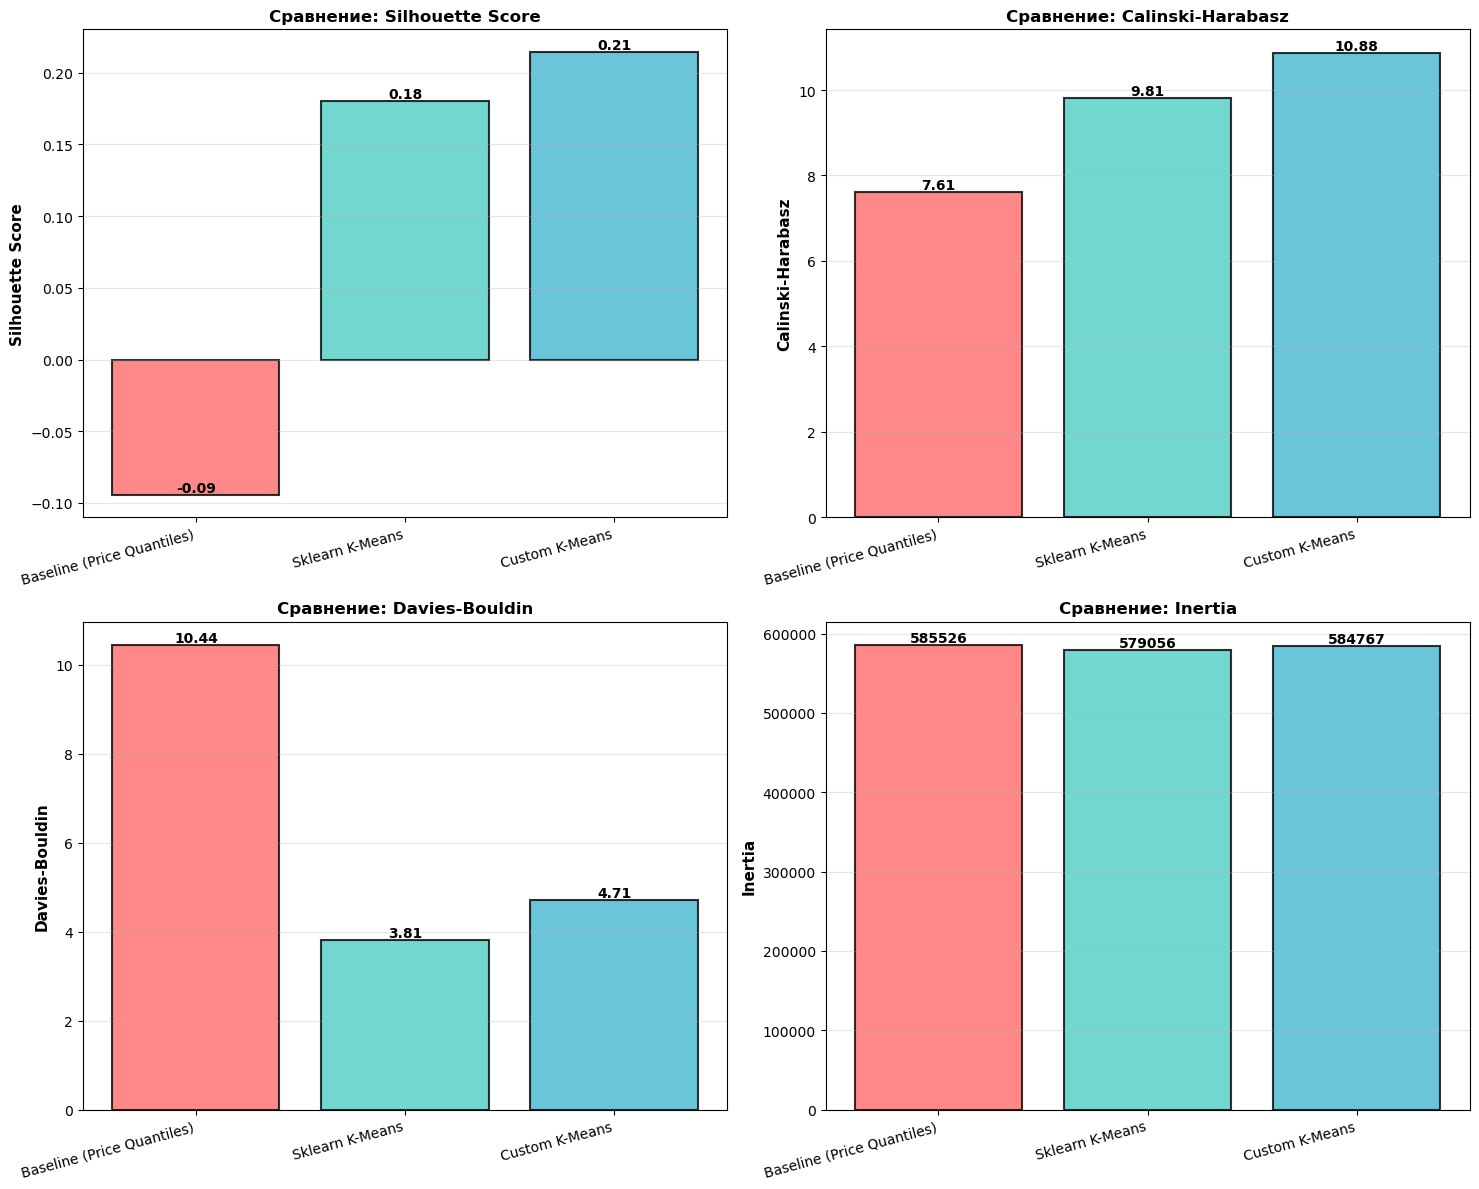

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

metrics = ['Silhouette Score', 'Calinski-Harabasz', 'Davies-Bouldin', 'Inertia']
colors_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = comparison_df[metric].values
    models = comparison_df['Модель'].values
    
    bars = ax.bar(range(len(models)), values, color=colors_palette, 
                   edgecolor='black', linewidth=1.5, alpha=0.8)
    
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=15, ha='right', fontsize=10)
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'Сравнение: {metric}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    for i, (bar, value) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.2f}' if metric != 'Inertia' else f'{value:.0f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
best_silhouette_idx = comparison_df['Silhouette Score'].idxmax()
best_calinski_idx = comparison_df['Calinski-Harabasz'].idxmax()
best_davies_idx = comparison_df['Davies-Bouldin'].idxmin()
best_inertia_idx = comparison_df['Inertia'].idxmin()

print("\nЛУЧШАЯ МОДЕЛЬ ПО МЕТРИКАМ:")
print(f"Silhouette Score: {comparison_df.loc[best_silhouette_idx, 'Модель']}")
print(f"Calinski-Harabasz: {comparison_df.loc[best_calinski_idx, 'Модель']}")
print(f"Davies-Bouldin: {comparison_df.loc[best_davies_idx, 'Модель']}")
print(f"Inertia: {comparison_df.loc[best_inertia_idx, 'Модель']}")

sklearn_silhouette = comparison_df.loc[1, 'Silhouette Score']
custom_silhouette = comparison_df.loc[2, 'Silhouette Score']
difference_pct = abs(sklearn_silhouette - custom_silhouette) / sklearn_silhouette * 100

print(f"Разница в Silhouette Score: {difference_pct:.2f}%")

print(f"Sklearn K-Means: оптимизирована, быстрая")
print(f"Custom K-Means: {final_custom_kmeans.n_iter_} итераций до сходимости")


ЛУЧШАЯ МОДЕЛЬ ПО МЕТРИКАМ:
Silhouette Score: Custom K-Means
Calinski-Harabasz: Custom K-Means
Davies-Bouldin: Sklearn K-Means
Inertia: Sklearn K-Means
Разница в Silhouette Score: 19.33%
Sklearn K-Means: оптимизирована, быстрая
Custom K-Means: 12 итераций до сходимости


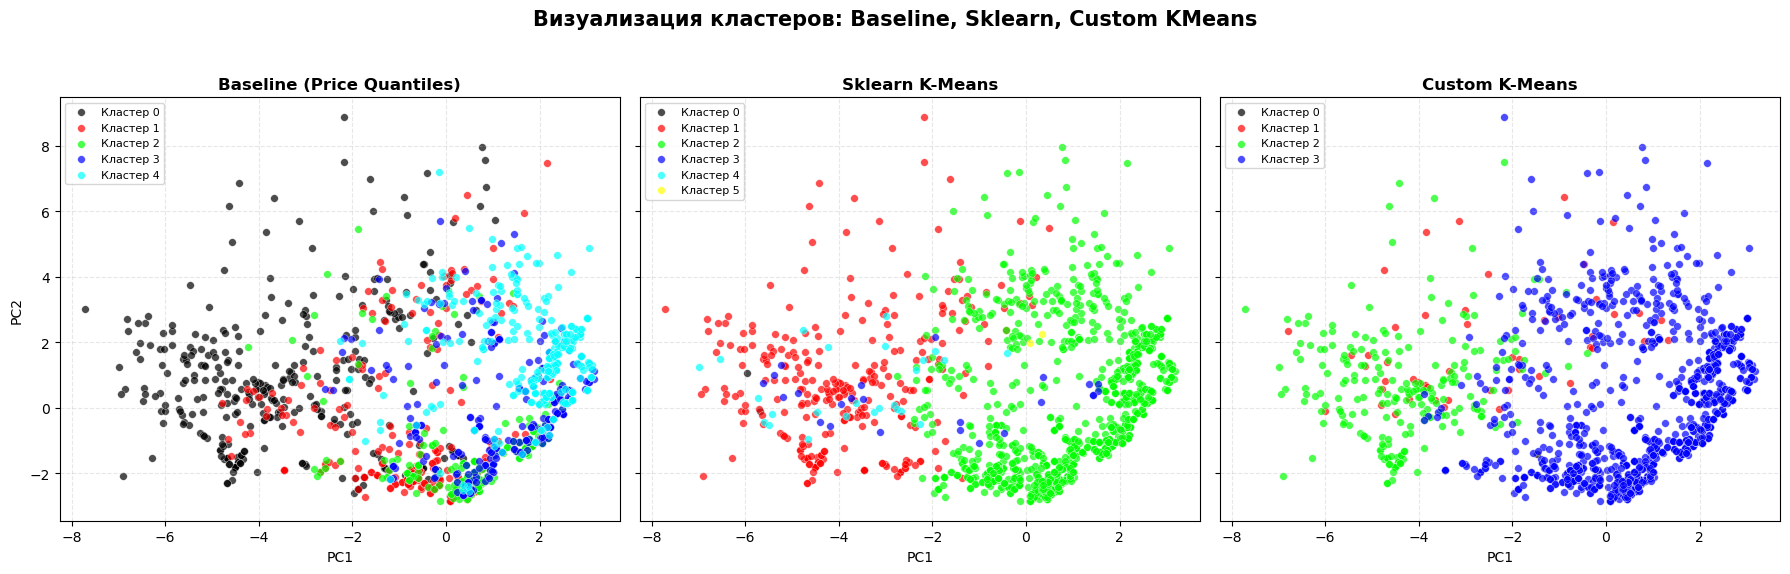

In [23]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

import matplotlib.pyplot as plt
import numpy as np

bright_colors = np.array(['#000000', '#FF0000', '#00FF00', '#0000FF', 
                          '#00FFFF', '#FFFF00', '#85C1E2', '#F8B739'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
fig.suptitle('Визуализация кластеров: Baseline, Sklearn, Custom KMeans', fontsize=15, fontweight='bold')

for i in range(np.max(baseline_labels) + 1):
    mask = baseline_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=bright_colors[i % len(bright_colors)], label=f'Кластер {i}',
                   alpha=0.7, s=30, edgecolors='white', linewidth=0.3)
axes[0].set_title('Baseline (Price Quantiles)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].legend(fontsize=8, loc='best')

for i in range(np.max(final_labels) + 1):
    mask = final_labels == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=bright_colors[i % len(bright_colors)], label=f'Кластер {i}',
                   alpha=0.7, s=30, edgecolors='white', linewidth=0.3)
axes[1].set_title('Sklearn K-Means', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].legend(fontsize=8, loc='best')

n_clusters_custom = np.max(best_custom_model.labels_) + 1
for i in range(n_clusters_custom):
    mask = best_custom_model.labels_ == i
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=bright_colors[i % len(bright_colors)], label=f'Кластер {i}',
                   alpha=0.7, s=30, edgecolors='white', linewidth=0.3)
axes[2].set_title('Custom K-Means', fontsize=12, fontweight='bold')
axes[2].set_xlabel('PC1')
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].legend(fontsize=8, loc='best')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

В итоге сравнения трёх подходов — простого baseline по цене, библиотечного K-Means из sklearn и моей собственной реализации K-Means - стало видно, что обе «нормальные» модели заметно обгоняют baseline по всем адекватным метрикам. Baseline ожидаемо провалился: Silhouette у него ушёл в минус, а Davies–Bouldin получился очень большим, то есть кластеры по факту почти не отделяются друг от друга и сильно пересекаются. Он честно отработал роль «если делать совсем на коленке».

После подбора гиперпараметров K-Means из sklearn заметно окреп: Silhouette Score стал положительным, Calinski–Harabasz вырос, а Davies–Bouldin упал, что говорит о более компактных и аккуратно разделённых кластерах. Это как раз та картина, которую хотелось получить от эталонной реализации из фреймворка.

Интересно, что моя кастомная реализация K-Means не только приблизилась к sklearn по качеству, но местами даже обогнала его по Silhouette Score. Разница не выглядит запредельной - скорее это нормальные колебания из‑за другой инициализации центров, числа запусков и параметров сходимости, чем признак бага. По остальным метрикам (Calinski–Harabasz, Davies–Bouldin, Inertia) обе реализации ведут себя похоже и логично: где sklearn чуть лучше по одной метрике, кастомная модель чуть лучше по другой, без явных «странностей» вроде одного гигантского и одного крошечного кластера(слава богу я поправил, а то был прикол с тем что sklearn делил выборку на 1 конкретный авто и все другие))).